This script explores probability of dying and at real implementaion of the [Gompertz–Makeham law of mortality](https://en.wikipedia.org/wiki/Gompertz%E2%80%93Makeham_law_of_mortality), based on data from [life tables](https://en.wikipedia.org/wiki/Life_table).

Data sources: [Japan](https://www.ipss.go.jp/p-toukei/JMD/00/index.html), [Tokyo](https://www.ipss.go.jp/p-toukei/JMD/13/index.html), [Kyoto](https://www.ipss.go.jp/p-toukei/JMD/26/index.html), [Shiga](https://www.ipss.go.jp/p-toukei/JMD/25/index.html) → "Life Tables"<br>
wiki > [List of Japanese prefectures by life expectancy](https://en.wikipedia.org/wiki/List_of_Japanese_prefectures_by_life_expectancy) <i>[(alternative)](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_Japanese_prefectures_by_life_expectancy_(alternative))</i> / [Продолжительность жизни в префектурах Японии](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_префектурах_Японии)<br />
[Demographics of Tokyo](https://en.wikipedia.org/wiki/Demographics_of_Tokyo#Percentage_surviving)<br>
[selection of colors](http://mal-bioit.ru/survey-web-colors)<br />
see also: [Nippon.com](https://www.nippon.com/en/search.html?s=life%20expectancy)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import re
from collections import namedtuple

In [3]:
# pd.options.display.max_rows=110

In [4]:
LANGS = ['en']  # languages of the charts (this setting doesn't have influence on tables)  #['en', 'ru', 'nolang']
YEAR = 2020
EXPLORE_PERIOD = True  # Change this value to 'False' to speed up work of the script, if the exploration is not required
WRITE_TABLE = False
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

NMB_PREF1 = 13        # number for Tokyo
NMB_PREF2 = 26        # number for Kyoto
NMB_PREF3 = 25        # number for Shiga

In [5]:
# This block of code extracts name of region from CSV-file with data.
# This name is used only to name correctly file with resuls of the script work

pattern_region_general = re.compile(r'(?<=^[\d.]{3}).*(?=(.ken|.to|.fu), Life tables)')  # what is in the most cases, like '47.Okinawa.ken'
pattern_region_1       = re.compile(r'(?<=^[\d.]{3}).*(?=, Life tables)')  # case of '01.Hokkaido' in the file Jp_01.csv
pattern_region_0       = re.compile(r'(?<=^).*(?=, Life tables)')  # case of 'Japan' in the file Jp_01.csv

def extract_name_of_region_from_file(region_nmb):
    with open(f"data-Life_tables/JpLT_{region_nmb:02}-total.csv", 'r') as fh:
        title_line = fh.readline()
        if region_nmb >= 2:
            fragment_name_found = re.search(pattern_region_general, title_line)
        elif region_nmb == 1:
            fragment_name_found = re.search(pattern_region_1, title_line)
        elif region_nmb == 0:
            fragment_name_found = re.search(pattern_region_0, title_line)
        else:
            raise ValueError(f"Not expected region number: {region_nmb}")
        name = fragment_name_found.group() if fragment_name_found else 'region name is not found'
    return name


name_pref1 = extract_name_of_region_from_file(NMB_PREF1)
print(f"Region #{NMB_PREF1} - {name_pref1}")

name_pref2 = extract_name_of_region_from_file(NMB_PREF2)
print(f"Region #{NMB_PREF2} - {name_pref2}")

name_pref3 = extract_name_of_region_from_file(NMB_PREF3)
print(f"Region #{NMB_PREF3} - {name_pref3}")

Region #13 - Tokyo
Region #26 - Kyoto
Region #25 - Shiga


<br>

In [7]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'nolang_name', 'color', 'style', 'width', 'alpha'])

In [8]:
# For overview, explore probability of dying at certain age during a some period
def read_single_csv_probability_for_given_age(nmb_region, age: str, suffix_for_columns=''):
    '''This function load data for percentage surviving for a single prefecture or a country as a whole'''
    df_m = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-males.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_m = df_m.loc[df_m['Age'] == age] \
               .drop(columns='Age') \
               .set_index('Year')
    df_m['qx'] = df_m['qx'] * 100
    # df_m = df_m.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_t = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-total.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_t = df_t.loc[df_t['Age'] == age] \
               .drop(columns='Age') \
               .set_index('Year')
    df_t['qx'] = df_t['qx'] * 100
    # df_t = df_t.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_f = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-females.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_f = df_f.loc[df_f['Age'] == age] \
               .drop(columns='Age') \
               .set_index('Year')
    df_f['qx'] = df_f['qx'] * 100
    # df_f = df_f.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('male', 'total', 'female')

    df['mΔf'] = df['male'] - df['female']     # No requirement for rounding since numbers are integers
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]

    return df


age_to_explore = '109'
df_to_explore = pd.DataFrame()
if EXPLORE_PERIOD:
    df_to_explore = pd.concat([
            read_single_csv_probability_for_given_age(0, age=age_to_explore),
            read_single_csv_probability_for_given_age(NMB_PREF1, age=age_to_explore, suffix_for_columns='_pref1'),
            read_single_csv_probability_for_given_age(NMB_PREF2, age=age_to_explore, suffix_for_columns='_pref2'),
            read_single_csv_probability_for_given_age(NMB_PREF3, age=age_to_explore, suffix_for_columns='_pref3')], axis='columns')

df_to_explore.loc[2000:]

,male,total,female,mΔf,ratio_mf,male_pref1,total_pref1,female_pref1,mΔf_pref1,ratio_mf_pref1,male_pref2,total_pref2,female_pref2,mΔf_pref2,ratio_mf_pref2,male_pref3,total_pref3,female_pref3,mΔf_pref3,ratio_mf_pref3
,,,,,,,,,,,,,,,,,,,,
2000,50.580,49.523,49.330,1.250,1.03,49.649,47.807,47.701,1.948,1.04,49.446,47.634,47.382,2.064,1.04,51.182,51.036,50.946,0.236,1.00
2001,50.673,49.421,49.162,1.511,1.03,50.036,48.589,48.378,1.658,1.03,50.431,48.839,48.649,1.782,1.04,50.018,50.898,51.348,-1.330,0.97
2002,50.084,48.833,48.600,1.484,1.03,50.053,47.517,47.126,2.927,1.06,50.785,47.240,46.751,4.034,1.09,50.807,50.395,50.159,0.648,1.01
2003,50.753,49.086,48.854,1.899,1.04,49.496,47.309,46.954,2.542,1.05,50.811,47.789,47.333,3.478,1.07,52.294,51.403,50.616,1.678,1.03
2004,50.174,48.846,48.634,1.540,1.03,48.572,47.595,47.490,1.082,1.02,50.928,48.633,48.380,2.548,1.05,51.864,51.447,51.170,0.694,1.01
2005,51.549,49.754,49.565,1.984,1.04,51.238,49.252,49.007,2.231,1.05,52.019,49.800,49.522,2.497,1.05,54.066,52.037,50.609,3.457,1.07
2006,50.744,49.353,49.214,1.530,1.03,50.842,48.322,48.127,2.715,1.06,51.288,49.358,49.002,2.286,1.05,50.194,51.113,51.518,-1.324,0.97
2007,50.363,49.440,49.361,1.002,1.02,49.865,48.166,47.997,1.868,1.04,50.710,49.330,48.942,1.768,1.04,50.788,50.541,50.460,0.328,1.01
2008,51.322,49.916,49.808,1.514,1.03,50.515,48.575,48.454,2.061,1.04,51.127,49.246,48.913,2.214,1.05,50.788,50.682,50.656,0.132,1.00


<br>

In [10]:
def read_single_csv(nmb_region, year, suffix_for_columns=''):
    '''This function load data for percentage surviving for a single prefecture or a country as a whole'''
    df_m = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-males.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_m = df_m.loc[df_m['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_m['qx'] = df_m['qx'] * 100
    df_m = df_m.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_t = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-total.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_t = df_t.loc[df_t['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_t['qx'] = df_t['qx'] * 100
    df_t = df_t.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_f = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-females.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_f = df_f.loc[df_f['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_f['qx'] = df_f['qx'] * 100
    df_f = df_f.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('male', 'total', 'female')

    df['mΔf'] = df['male'] - df['female']     # No requirement for rounding since numbers are integers
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]

    return df

df = pd.concat([
        read_single_csv(0, year=YEAR),
        read_single_csv(NMB_PREF1, year=YEAR, suffix_for_columns='_pref1'),
        read_single_csv(NMB_PREF2, year=YEAR, suffix_for_columns='_pref2'),
        read_single_csv(NMB_PREF3, year=YEAR, suffix_for_columns='_pref3')], axis='columns')

# drop values for 110, since this record doesn't have sense
df.drop(index=110, inplace=True)

df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109]]

,male,total,female,mΔf,ratio_mf,male_pref1,total_pref1,female_pref1,mΔf_pref1,ratio_mf_pref1,male_pref2,total_pref2,female_pref2,mΔf_pref2,ratio_mf_pref2,male_pref3,total_pref3,female_pref3,mΔf_pref3,ratio_mf_pref3
,,,,,,,,,,,,,,,,,,,,
0,0.187,0.180,0.174,0.013,1.07,0.129,0.137,0.146,-0.017,0.88,0.120,0.129,0.139,-0.019,0.86,0.150,0.183,0.218,-0.068,0.69
1,0.026,0.022,0.018,0.008,1.44,0.018,0.013,0.009,0.009,2.00,0.002,0.009,0.019,-0.017,0.11,0.023,0.032,0.044,-0.021,0.52
5,0.007,0.007,0.007,0.000,1.00,0.010,0.010,0.009,0.001,1.11,0.005,0.006,0.007,-0.002,0.71,0.006,0.006,0.007,-0.001,0.86
10,0.005,0.006,0.006,-0.001,0.83,0.004,0.006,0.008,-0.004,0.50,0.001,0.004,0.007,-0.006,0.14,0.004,0.004,0.005,-0.001,0.80
20,0.039,0.031,0.022,0.017,1.77,0.038,0.027,0.015,0.023,2.53,0.039,0.029,0.022,0.017,1.77,0.047,0.037,0.027,0.020,1.74
30,0.052,0.040,0.027,0.025,1.93,0.038,0.031,0.024,0.014,1.58,0.038,0.028,0.020,0.018,1.90,0.031,0.029,0.026,0.005,1.19
40,0.092,0.077,0.063,0.029,1.46,0.083,0.065,0.046,0.037,1.80,0.093,0.073,0.058,0.035,1.60,0.093,0.081,0.072,0.021,1.29
50,0.247,0.198,0.147,0.100,1.68,0.238,0.191,0.141,0.097,1.69,0.228,0.173,0.122,0.106,1.87,0.191,0.143,0.088,0.103,2.17
60,0.609,0.444,0.281,0.328,2.17,0.616,0.460,0.301,0.315,2.05,0.596,0.417,0.237,0.359,2.51,0.462,0.344,0.238,0.224,1.94


In [11]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109], ['male', 'male_pref1', 'male_pref2', 'male_pref3', 'female', 'female_pref1', 'female_pref2', 'female_pref3']]

,male,male_pref1,male_pref2,male_pref3,female,female_pref1,female_pref2,female_pref3
,,,,,,,,
0,0.187,0.129,0.120,0.150,0.174,0.146,0.139,0.218
1,0.026,0.018,0.002,0.023,0.018,0.009,0.019,0.044
5,0.007,0.010,0.005,0.006,0.007,0.009,0.007,0.007
10,0.005,0.004,0.001,0.004,0.006,0.008,0.007,0.005
20,0.039,0.038,0.039,0.047,0.022,0.015,0.022,0.027
30,0.052,0.038,0.038,0.031,0.027,0.024,0.020,0.026
40,0.092,0.083,0.093,0.093,0.063,0.046,0.058,0.072
50,0.247,0.238,0.228,0.191,0.147,0.141,0.122,0.088
60,0.609,0.616,0.596,0.462,0.281,0.301,0.237,0.238


<br>

<h4>Explore the "plateau"  (21–30 years)</h4>
The code below calculates average values of the probability of dying for the "plateau", and how much people would live if throughout their lifetime the probability of dying will be the same as in this interval.

In [13]:
# explore the the "plateau" manually, if we want
# df.loc[16:40]

In [14]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = pd.concat([
    df.loc[plateau_years, ['male', 'total', 'female']].mean(),
    df.loc[plateau_years, ['male_pref1', 'total_pref1', 'female_pref1']].mean().rename(index={'male_pref1':'male', 'total_pref1':'total', 'female_pref1':'female'}),
    df.loc[plateau_years, ['male_pref2', 'total_pref2', 'female_pref2']].mean().rename(index={'male_pref2':'male', 'total_pref2':'total', 'female_pref2':'female'}),
    df.loc[plateau_years, ['male_pref3', 'total_pref3', 'female_pref3']].mean().rename(index={'male_pref3':'male', 'total_pref3':'total', 'female_pref3':'female'})
], axis='columns').T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['Japan', name_pref1, name_pref2, name_pref3]
dfe.round(3)

,male,total,female,ratio_mf
Japan,0.050,0.038,0.026,1.98
Tokyo,0.038,0.031,0.023,1.65
Kyoto,0.047,0.033,0.019,2.47
Shiga,0.041,0.035,0.027,1.51


In [15]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_total'] = dfe['total'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,total,female,ratio_mf,le_ageless_male,le_ageless_total,le_ageless_female
Japan,0.050,0.038,0.026,1.98,1980,2604,3921
Tokyo,0.038,0.031,0.023,1.65,2597,3246,4291
Kyoto,0.047,0.033,0.019,2.47,2127,3021,5263
Shiga,0.041,0.035,0.027,1.51,2439,2873,3676


<br>

<h4>Explore the zone of the Gompertz law of mortality  (40–90 years)</h4>
The code below calculates the average annual increase the probability of dying (in percent) and the period during that this indicator doubles (in years), <b>based on the values at the endpoints</b>.<br><i>
(Calculations based on approximation are below, under a chart.)</i>

In [17]:
def calculate_increase_rate_and_doubling_period(age1: int, age2: int, v1: float, v2: float):
    '''
    This function calculate two characteristics of a geometric progression (in the context of aging)
    - by what percentage does the value increase every year (in percent)
    - period of doubling (in years)
    '''
    q = math.pow((v2 / v1),
                  1 / (age2 - age1))  # find 'common ratio' of the geometric progression
                                      # (age2 - age1) √ (v2 / v1)      – (age2-age1)th root of (v2 / v1)

    T = math.log(2, q)  # doubling period:    log base 'q' of 2
    return (q - 1) * 100, T

In [18]:
age_gompertz_start = 40
age_gompertz_stop  = 90
print(" increase_rate(%)  doubling   | increase_rate(%)  doubling")
print("             male             |            female")
for region, pref in zip(['Japan', name_pref1, name_pref2, name_pref3], ['', '_pref1', '_pref2', '_pref3']): 
    male_rate_perc, male_period_double = \
        calculate_increase_rate_and_doubling_period(
            age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'male'+pref], df.loc[age_gompertz_stop, 'male'+pref])
    female_rate_perc, female_period_double = \
        calculate_increase_rate_and_doubling_period(
            age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'female'+pref], df.loc[age_gompertz_stop, 'female'+pref])
    print(f"{region:5}: {male_rate_perc:5.2f} %  {male_period_double:5.2f} years   |" +
          f"      {female_rate_perc:5.2f} %  {female_period_double:5.2f} years")

 increase_rate(%)  doubling   | increase_rate(%)  doubling
             male             |            female
Japan: 10.61 %   6.87 years   |      10.42 %   6.99 years
Tokyo: 10.73 %   6.80 years   |      11.01 %   6.64 years
Kyoto: 10.47 %   6.96 years   |      10.44 %   6.98 years
Shiga: 10.50 %   6.94 years   |      10.06 %   7.23 years


<br>

In [20]:
def create_table(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    prec = 3
    for age in [0, 1] + list(range(5, 106, 5)) + [109]:
        ser = df.loc[age]
        st += '\n' + '|-\n' + \
            f'|style="padding-right:3ex;"| {age} ' + \
            f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['male'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_pref1'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_pref1'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_pref1']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_pref2'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_pref2'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_pref2']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_pref3'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_pref3'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_pref3']:0.2f}'

    # fix microbugs that can happened due to nuances of calculations and rounding
    st = st.replace('color:darkgray;padding-right:3ex;"| -0.0 ', 'color:darkgray;padding-right:3ex;"| 0.0 ')
    
    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits
        st = st.replace('padding-right:3ex;', 'padding-right:2.5ex;')

    st = table_header + st + '\n|}'
    return st
        

if WRITE_TABLE:
    table_code = create_table(df, file_header='Probability_of_dying_extended -en.txt', lang='en')
    with open(f"output/Table code for probability of dying extended -{YEAR} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

    table_code = create_table(df, file_header='Probability_of_dying_extended -ru.txt', lang='ru')
    with open(f"output/Table code for probability of dying extended -{YEAR} -ru.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

<br>
<br>

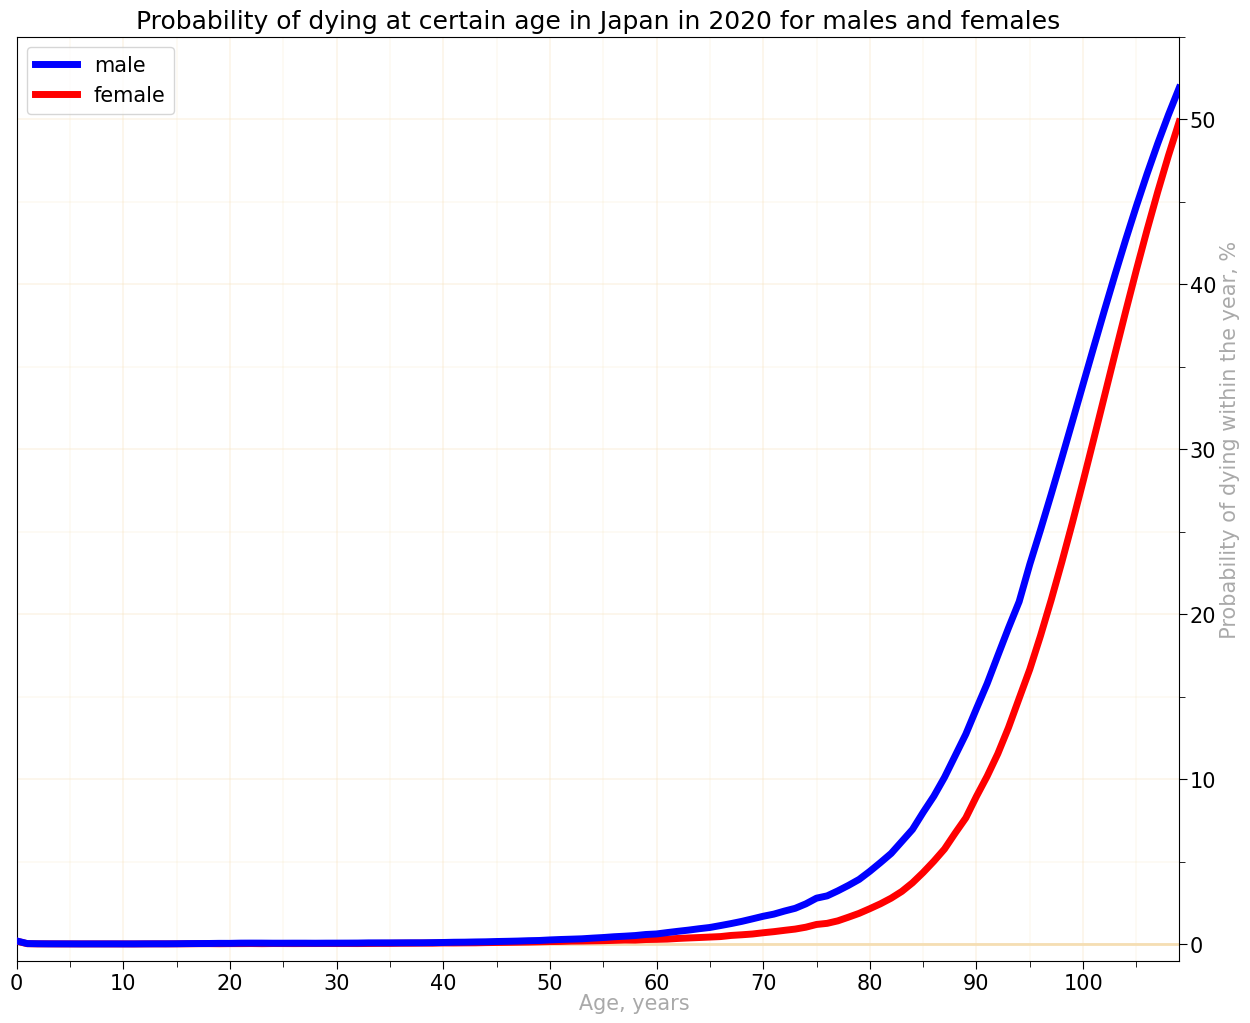

In [22]:
def create_chart(
        df, lang='en', dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)   # font size for tick labels
    plt.yticks(fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 55
    plt.xlim(0, 109)
    plt.ylim(-1, 55)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("          Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                  Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=3)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png",
                    bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",   ru_name="мужчины", nolang_name="♂", color='blue', style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", nolang_name="∑", color='lightgrey', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female", ru_name="женщины", nolang_name="♀", color='red',  style='-', width=5, alpha=1)
}

for lang in LANGS:
    create_chart(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            title_en=f"Probability of dying at certain age in Japan in {YEAR} for males and females",
            title_ru=f"Вероятность смерти в определённом возрасте в Японии в {YEAR} для мужчин и женщин",
            file_name=f"Probability of Dying at Certain Age in Japan in {YEAR}")

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.051,  ♀: 0.026
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 1980,  ♀: 3920

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.001699 * exp(0.098861 * x)
Coefficient of determination (R²): 0.986
Annual increase: 10.391 %,   doubling period:  7.011 years

Model for female: y = 0.001090 * exp(0.095117 * x)
Coefficient of determination (R²): 0.883
Annual increase:  9.979 %,   doubling period:  7.287 years



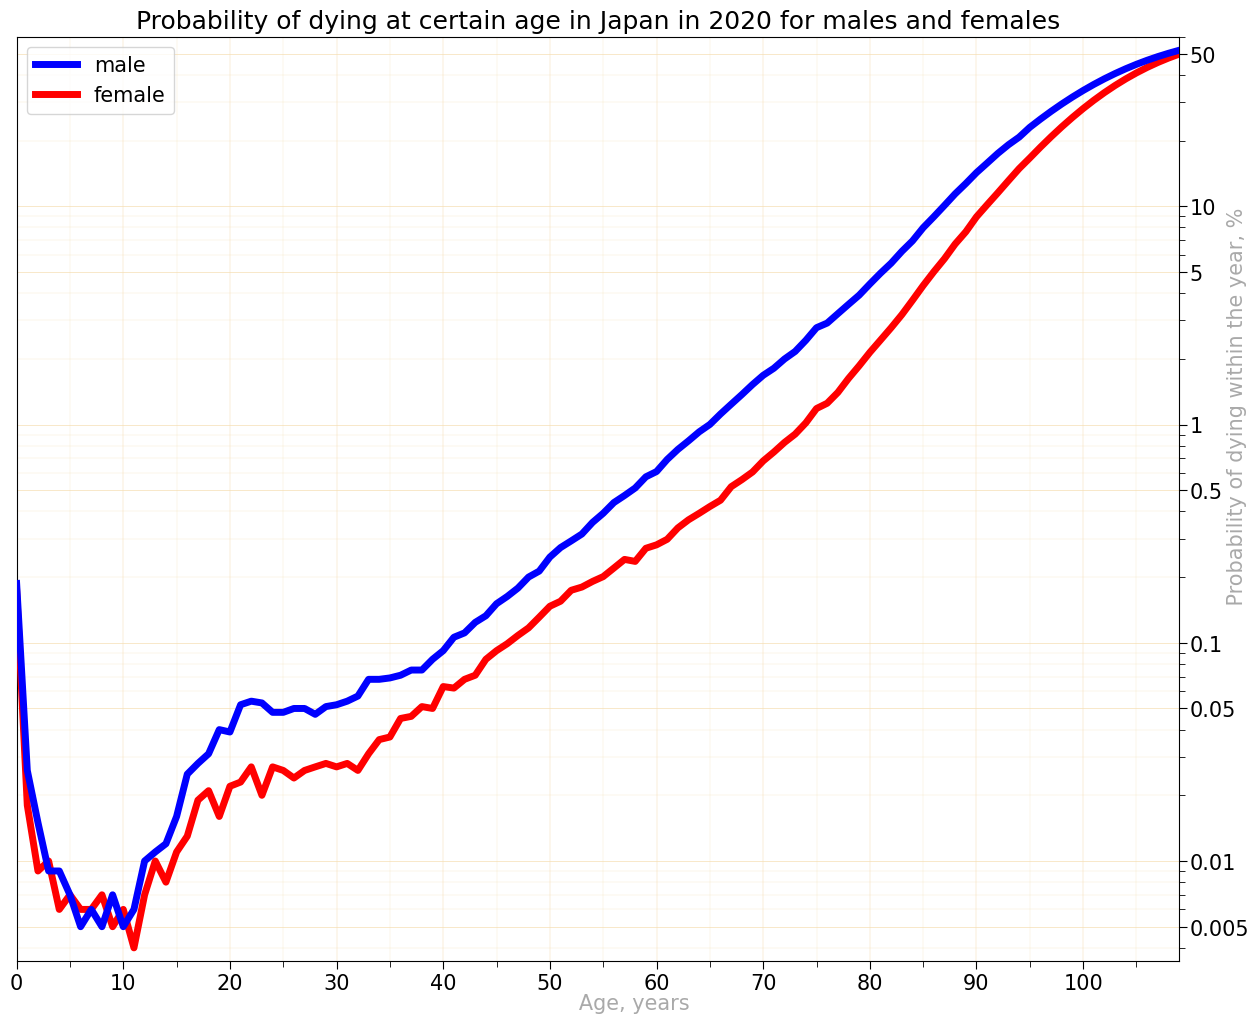

In [23]:
def create_chart_log(
        df, lang='en', dd_display='', ncol=1,
        plateau_years=plateau_years, show_plateau=False,
        age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()                 # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.0035, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # for y_milestone in [0.1, 1, 10]:
    #     plt.axhline(y=y_milestone, color='wheat', linewidth=0.5)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("           Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                            Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    # Calculate and show statistics about "plateau" (21–30 years, including endpoints)
    print(f"  —— The zone of the 'plateau' ({plateau_years.start}–{plateau_years.stop} years, incl.) ——")

    plateau_mortality_male   = df.loc['male', plateau_years].mean()
    plateau_mortality_female = df.loc['female', plateau_years].mean()
    print(f"Average mortality rate at the plateau, %:  ♂: {plateau_mortality_male:.3f},  ♀: {plateau_mortality_female:.3f}")
    
    le_average_plateau_male   = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_male)
    le_average_plateau_female = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_female)
    print("Life expectancy based on the average mortality rate at the plateau, years:  " +
          f"♂: {round(le_average_plateau_male, -1)},  ♀: {round(le_average_plateau_female, -1)}" +
          '\n')

    if show_plateau:  # show horizontal lines for the "plateaux"
        for y_plateau in [plateau_mortality_male, plateau_mortality_female]:
             plt.hlines(y_plateau, plateau_years.start, plateau_years.stop, color='lime', linewidth=2, alpha=0.5)

    # Calculate and show statistics about the zone of the Gompertz law of mortality (40–90 years)
    print(f"  —— The zone of the Gompertz law of mortality ({age_gompertz_start}–{age_gompertz_stop} age_gompertz_stop) ——")

    # Generate x-values for the considered interval
    x_gompertz = np.linspace(age_gompertz_start, age_gompertz_stop, age_gompertz_stop-age_gompertz_start+1)

    for group in ['male', 'female']:
        y_gompertz = df.loc[group, x_gompertz].values    # take the y values
        ln_y = np.log(y_gompertz)                        # take the logarithm of the y values
        b, ln_a = np.polyfit(x_gompertz, ln_y, deg=1)    # do linear regression
                                                         #    b - slope of the line
                                                         #    b - intersection of the 'ln a' with the y-axis
        a = np.exp(ln_a)                                 # recover the amplitude of the exponent
        print(f"Model for {group:>6}: y = {a:.6f} * exp({b:.6f} * x)")

        y_fit = a * np.exp(b * x_gompertz)               # approximated function

        ss_res = np.sum((y_gompertz - y_fit) ** 2)                # calculate the coefficient of determination
        ss_tot = np.sum((y_gompertz - np.mean(y_gompertz)) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f"Coefficient of determination (R²): {r2:.3f}")

        rate_perc, period_double = calculate_increase_rate_and_doubling_period(
            x_gompertz[0], x_gompertz[-1], y_fit[0], y_fit[-1])
        print(f"Annual increase: {rate_perc:6.3f} %,   doubling period: {period_double:6.3f} years")
        print()

        if show_gompertz:  # show sloped lines for the zone where Gompertz law is observed
            plt.plot(x_gompertz, y_fit, color='orange', linewidth=dd_display[group].width, alpha=0.5)
    
    plt.legend(loc='upper left', fontsize=15, ncol=ncol)
    
    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -nolang' if lang=='nolang' else ''}.png",
                    bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
            title_en=f"Probability of dying at certain age in Japan in {YEAR} for males and females",
            title_ru=f"Вероятность смерти в определённом возрасте в Японии в {YEAR} для мужчин и женщин",
            file_name=f"Probability of Dying at Certain Age in Japan in {YEAR} -log")

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.051,  ♀: 0.026
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 1980,  ♀: 3920

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.001699 * exp(0.098861 * x)
Coefficient of determination (R²): 0.986
Annual increase: 10.391 %,   doubling period:  7.011 years

Model for female: y = 0.001090 * exp(0.095117 * x)
Coefficient of determination (R²): 0.883
Annual increase:  9.979 %,   doubling period:  7.287 years



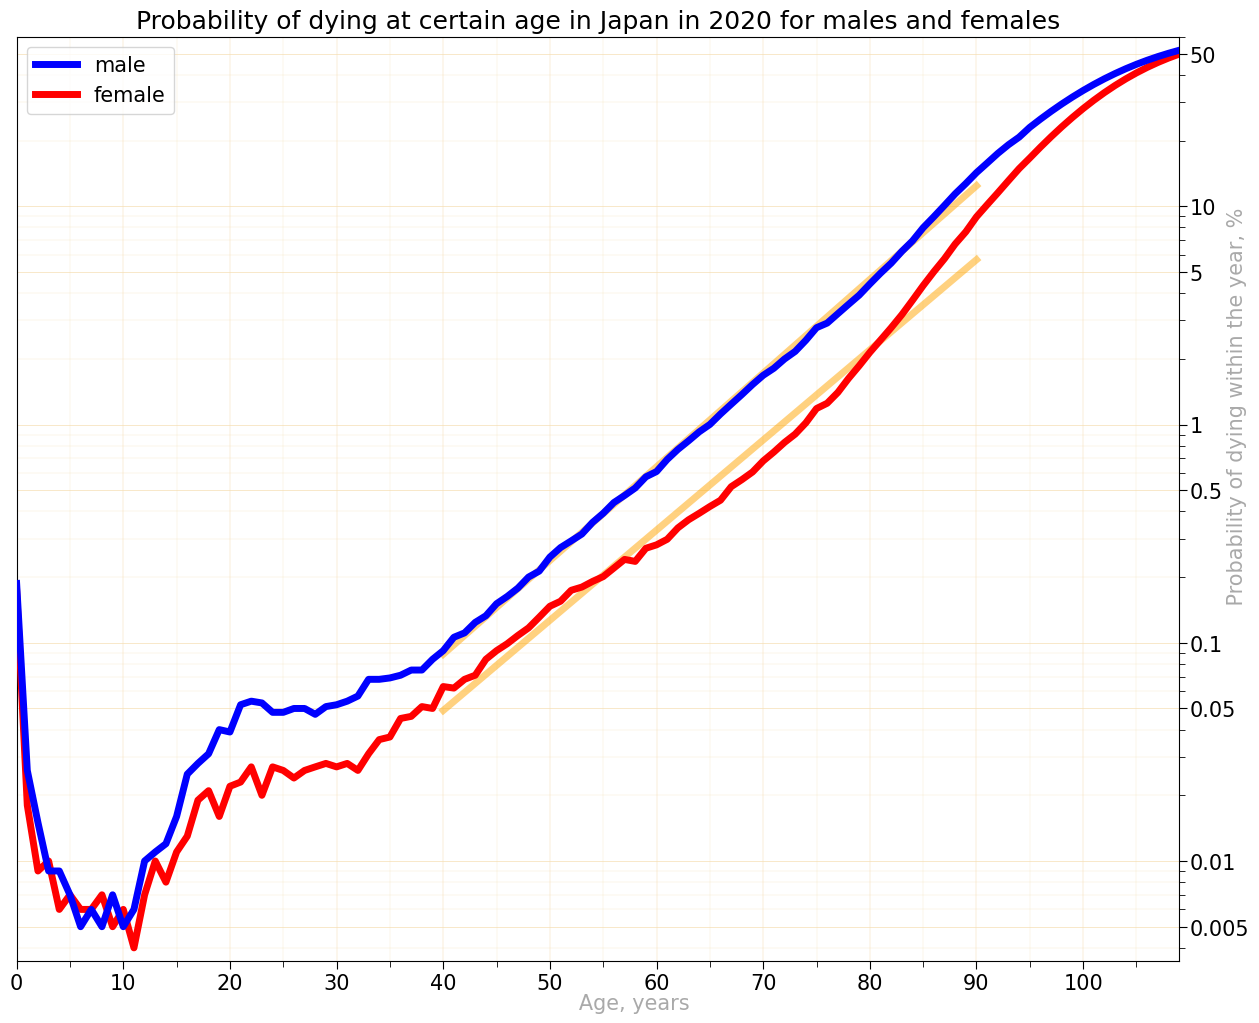

In [24]:
for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
            title_en=f"Probability of dying at certain age in Japan in {YEAR} for males and females",
            title_ru=f"Вероятность смерти в определённом возрасте в Японии в {YEAR} для мужчин и женщин",
            file_name=f"Probability of Dying at Certain Age in Japan in {YEAR} -gompertz")

<br>
<br>

In [26]:
# play beep to denote completion of the program
import IPython.display as ipd
import numpy as np

# manually generated sound
t = 1  # time is seconds
beep = np.sin(2*np.pi*400*np.arange(10000*t)/10000)
ipd.Audio(beep, rate=10000, autoplay=True)